## Purpose: Define the explainability workflow for the final CatBoost cart-to-purchase model.

# 04 — Model Explainability and XAI

This notebook explains the final CatBoost model using SHAP values to identify the behavioral, item-level, and temporal factors that most influence whether a carted item is purchased within 14 days.

**Main objectives:**
- Load the saved final CatBoost model and the temporal test set
- Calculate global feature importance using SHAP
- Explain individual high- and low-probability cart cases
- Translate model explanations into actionable personalization strategies
- Save article-ready explainability figures and tables

In [1]:
# Purpose: Import libraries required for loading the model and conducting SHAP-based explainability analysis.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

In [2]:
# Purpose: Locate project files, load the final CatBoost model, and recreate the untouched temporal test set.

current_path = Path.cwd().resolve()

project_root = next(
    (
        candidate
        for candidate in [current_path, *current_path.parents]
        if (candidate / "data").exists()
    ),
    current_path
)

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"
models_dir = project_root / "outputs" / "models"

modeling_data_path = (
    processed_data_dir / "cart_purchase_modeling_dataset.csv"
)

model_path = (
    models_dir / "final_catboost_cart_purchase_model.cbm"
)

modeling_dataset = pd.read_csv(
    modeling_data_path,
    parse_dates=["cart_time"]
)

target_column = "purchased_within_14_days"

non_feature_columns = [
    "visitorid",
    "itemid",
    "cart_time",
    target_column
]

model_feature_columns = [
    column
    for column in modeling_dataset.columns
    if column not in non_feature_columns
]

split_time = modeling_dataset["cart_time"].quantile(0.80)

test_df = modeling_dataset[
    modeling_dataset["cart_time"] >= split_time
].copy()

X_test = test_df[model_feature_columns]
y_test = test_df[target_column]

final_catboost_model = CatBoostClassifier()
final_catboost_model.load_model(model_path)

print(f"Project root: {project_root}")
print(f"Loaded model: {model_path.name}")
print(f"Temporal test set shape: {X_test.shape}")
print(f"Test purchase rate: {y_test.mean() * 100:.2f}%")

Project root: F:\ecommerce-recommender-xai
Loaded model: final_catboost_cart_purchase_model.cbm
Temporal test set shape: (11277, 23)
Test purchase rate: 29.27%


In [3]:
# Purpose: Create a reproducible representative test sample for efficient SHAP analysis.

shap_sample_size = min(3000, len(X_test))

X_shap = X_test.sample(
    n=shap_sample_size,
    random_state=RANDOM_STATE
)

y_shap = y_test.loc[X_shap.index]

print(f"SHAP sample shape: {X_shap.shape}")
print(f"Purchase rate in SHAP sample: {y_shap.mean() * 100:.2f}%")

SHAP sample shape: (3000, 23)
Purchase rate in SHAP sample: 28.97%


In [4]:
# Purpose: Calculate SHAP values that quantify each feature's contribution to predicted purchase probability.

shap_explainer = shap.TreeExplainer(final_catboost_model)

shap_values = shap_explainer(X_shap)

print("SHAP values calculated successfully.")
print("SHAP value matrix shape:", shap_values.values.shape)

SHAP values calculated successfully.
SHAP value matrix shape: (3000, 23)


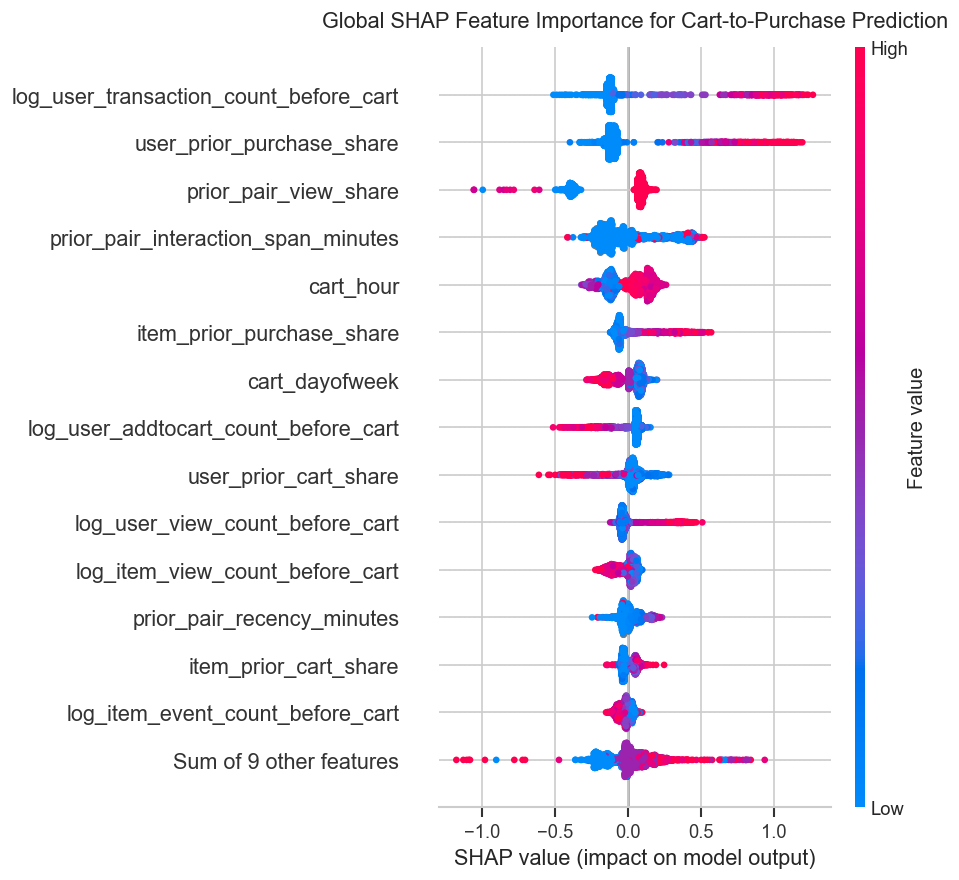

In [5]:
# Purpose: Visualize and save global SHAP feature importance across the representative temporal test sample.

plt.figure(figsize=(10, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "Global SHAP Feature Importance for Cart-to-Purchase Prediction",
    fontsize=13,
    pad=12
)

plt.tight_layout()

plt.savefig(
    figures_dir / "11_shap_global_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# Purpose: Calculate and save mean absolute SHAP importance values for all model features.

global_shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_absolute_shap_value": np.abs(
        shap_values.values
    ).mean(axis=0)
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "mean_absolute_shap_value",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap_importance.to_csv(
    tables_dir / "07_shap_global_feature_importance.csv",
    index=False
)

display(global_shap_importance)

,feature,mean_absolute_shap_value
0,log_user_transaction_count_before_cart,0.2211
1,user_prior_purchase_share,0.2049
2,prior_pair_view_share,0.1837
3,prior_pair_interaction_span_minutes,0.1728
4,cart_hour,0.1207
5,item_prior_purchase_share,0.1018
6,cart_dayofweek,0.0846
7,log_user_addtocart_count_before_cart,0.0809
8,user_prior_cart_share,0.0726
9,log_user_view_count_before_cart,0.0664


## Global SHAP findings

- The most influential feature was the user's prior transaction count, followed by the user's prior purchase share.
- Thus, historical purchase propensity was more important than item popularity alone for predicting whether a carted item would be purchased.
- Same user-item interaction history was also influential, particularly the share of prior interactions that were views and the time span from first interaction to cart addition.
- Cart hour and day of week had meaningful but secondary influence, indicating temporal variation in cart conversion behavior.

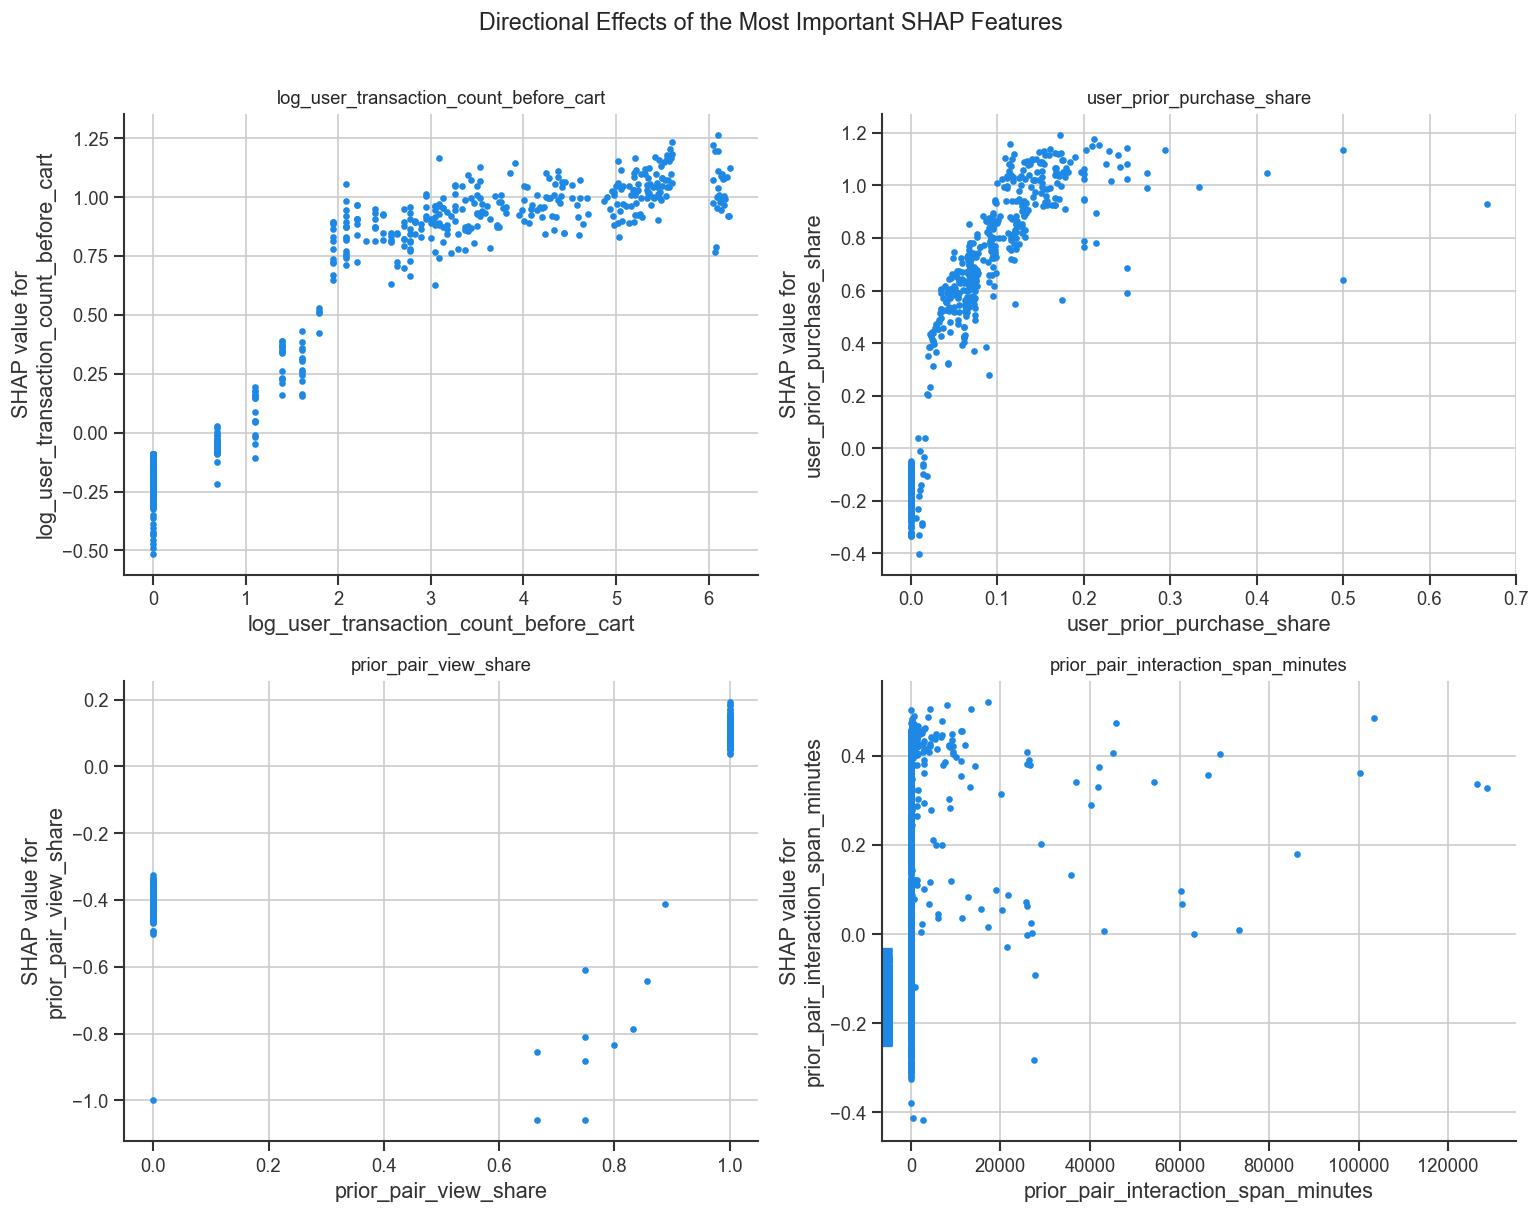

In [8]:
# Purpose: Visualize and save how the four most important features affect predicted purchase probability.

top_shap_features = global_shap_importance[
    "feature"
].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_shap_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_shap,
        interaction_index=None,
        ax=ax,
        show=False
    )
    ax.set_title(feature, fontsize=11)

fig.suptitle(
    "Directional Effects of the Most Important SHAP Features",
    fontsize=14,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    figures_dir / "12_shap_top_feature_dependence_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Purpose: Select one high-probability purchased cart and one low-probability non-purchased cart for local explanation.

shap_case_summary = test_df.loc[
    X_shap.index,
    ["visitorid", "itemid", "cart_time", "purchased_within_14_days"]
].copy()

shap_case_summary["predicted_purchase_probability"] = (
    final_catboost_model.predict_proba(X_shap)[:, 1]
)

high_probability_purchase_index = shap_case_summary[
    shap_case_summary["purchased_within_14_days"] == 1
]["predicted_purchase_probability"].idxmax()

low_probability_non_purchase_index = shap_case_summary[
    shap_case_summary["purchased_within_14_days"] == 0
]["predicted_purchase_probability"].idxmin()

selected_shap_cases = shap_case_summary.loc[
    [
        high_probability_purchase_index,
        low_probability_non_purchase_index
    ]
].copy()

selected_shap_cases.index = [
    "High-probability purchased cart",
    "Low-probability non-purchased cart"
]

display(selected_shap_cases)

,visitorid,itemid,cart_time,purchased_within_14_days,predicted_purchase_probability
High-probability purchased cart,1150086,196540,2015-08-17 21:49:20.993,1,0.8832
Low-probability non-purchased cart,962057,214418,2015-08-22 13:18:41.562,0,0.0257


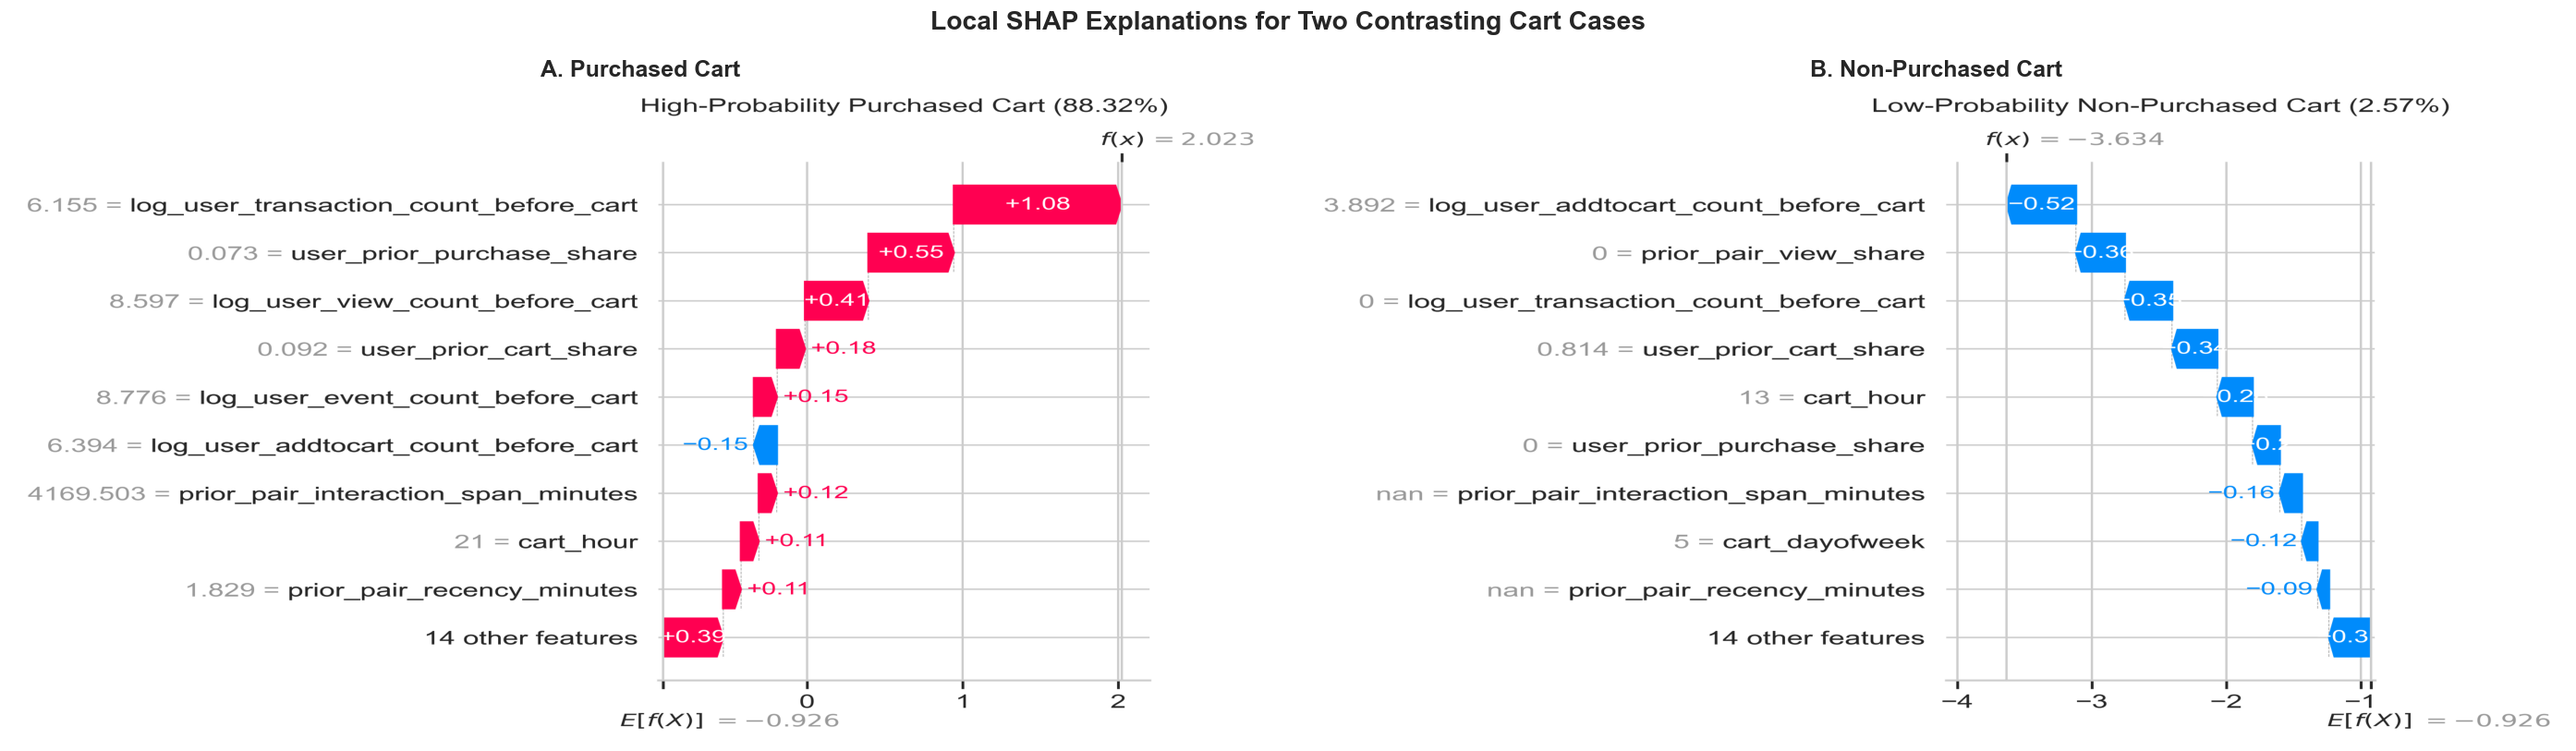

Saved combined figure to: F:\ecommerce-recommender-xai\outputs\figures\13_shap_local_waterfall_comparison.png


In [14]:
# Purpose: Create non-overlapping side-by-side SHAP waterfall explanations for two contrasting cart cases.

high_case_position = X_shap.index.get_loc(high_probability_purchase_index)
low_case_position = X_shap.index.get_loc(low_probability_non_purchase_index)

high_waterfall_path = figures_dir / "13a_shap_high_probability_waterfall.png"
low_waterfall_path = figures_dir / "13b_shap_low_probability_waterfall.png"
comparison_path = figures_dir / "13_shap_local_waterfall_comparison.png"

# Create and save the high-probability case separately.
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[high_case_position], max_display=10, show=False)
plt.title("High-Probability Purchased Cart (88.32%)", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig(high_waterfall_path, dpi=300, bbox_inches="tight")
plt.close()

# Create and save the low-probability case separately.
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[low_case_position], max_display=10, show=False)
plt.title("Low-Probability Non-Purchased Cart (2.57%)", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig(low_waterfall_path, dpi=300, bbox_inches="tight")
plt.close()

# Combine the two already-rendered charts into one clean, side-by-side figure.
high_image = plt.imread(high_waterfall_path)
low_image = plt.imread(low_waterfall_path)

fig, axes = plt.subplots(1, 2, figsize=(24, 7))

axes[0].imshow(high_image, aspect="auto")
axes[0].axis("off")
axes[0].set_title("A. Purchased Cart", fontsize=15, fontweight="bold", pad=8)

axes[1].imshow(low_image, aspect="auto")
axes[1].axis("off")
axes[1].set_title("B. Non-Purchased Cart", fontsize=15, fontweight="bold", pad=8)

fig.suptitle(
    "Local SHAP Explanations for Two Contrasting Cart Cases",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.04,
    top=0.88,
    wspace=0.03
)

plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved combined figure to: {comparison_path}")

In [11]:
# Purpose: Save the feature values of the two locally explained cart cases for transparent interpretation.

local_case_feature_table = X_shap.loc[
    [
        high_probability_purchase_index,
        low_probability_non_purchase_index
    ]
].T.copy()

local_case_feature_table.columns = [
    "high_probability_purchased_cart",
    "low_probability_non_purchased_cart"
]

local_case_feature_table.insert(
    0,
    "feature",
    local_case_feature_table.index
)

local_case_feature_table.to_csv(
    tables_dir / "08_shap_local_case_feature_values.csv",
    index=False
)

display(local_case_feature_table)

,feature,high_probability_purchased_cart,low_probability_non_purchased_cart
has_prior_pair_interaction,has_prior_pair_interaction,1.0000,0.0000
missing_prior_pair_timing,missing_prior_pair_timing,0.0000,1.0000
log_prior_pair_event_count,log_prior_pair_event_count,1.0986,0.0000
log_prior_pair_view_count,log_prior_pair_view_count,1.0986,0.0000
log_prior_pair_transaction_count,log_prior_pair_transaction_count,0.0000,0.0000
log_user_event_count_before_cart,log_user_event_count_before_cart,8.7765,4.0943
log_user_view_count_before_cart,log_user_view_count_before_cart,8.5966,2.4849
log_user_addtocart_count_before_cart,log_user_addtocart_count_before_cart,6.3936,3.8918
log_user_transaction_count_before_cart,log_user_transaction_count_before_cart,6.1549,0.0000
log_item_event_count_before_cart,log_item_event_count_before_cart,2.7081,2.1972


In [16]:
# Purpose: Create and save a table of the strongest local SHAP contributions for the two contrasting cart cases.

def build_local_shap_table(case_position, case_name):
    case_values = X_shap.iloc[case_position]
    case_shap_values = shap_values[case_position].values

    local_table = pd.DataFrame({
        "case": case_name,
        "feature": X_shap.columns,
        "feature_value": case_values.values,
        "shap_contribution": case_shap_values,
        "effect_on_purchase_prediction": np.where(
            case_shap_values > 0,
            "Increases predicted purchase likelihood",
            "Decreases predicted purchase likelihood"
        )
    })

    return local_table.sort_values(
        "shap_contribution",
        key=lambda column: column.abs(),
        ascending=False
    )

high_local_shap_table = build_local_shap_table(
    high_case_position,
    "High-probability purchased cart"
)

low_local_shap_table = build_local_shap_table(
    low_case_position,
    "Low-probability non-purchased cart"
)

local_shap_comparison = pd.concat(
    [
        high_local_shap_table.head(10),
        low_local_shap_table.head(10)
    ],
    ignore_index=True
)

local_shap_table_path = tables_dir / "09_shap_local_case_top_contributions.csv"
local_shap_comparison.to_csv(local_shap_table_path, index=False)

display(local_shap_comparison)

print(f"Saved local SHAP contribution table to: {local_shap_table_path}")

,case,feature,feature_value,shap_contribution,effect_on_purchase_prediction
0,High-probability purchased cart,log_user_transaction_count_before_cart,6.1549,1.0787,Increases predicted purchase likelihood
1,High-probability purchased cart,user_prior_purchase_share,0.0725,0.5498,Increases predicted purchase likelihood
2,High-probability purchased cart,log_user_view_count_before_cart,8.5966,0.4078,Increases predicted purchase likelihood
3,High-probability purchased cart,user_prior_cart_share,0.0921,0.1803,Increases predicted purchase likelihood
4,High-probability purchased cart,log_user_event_count_before_cart,8.7765,0.1484,Increases predicted purchase likelihood
5,High-probability purchased cart,log_user_addtocart_count_before_cart,6.3936,-0.1482,Decreases predicted purchase likelihood
6,High-probability purchased cart,prior_pair_interaction_span_minutes,"4,169.5028",0.1170,Increases predicted purchase likelihood
7,High-probability purchased cart,cart_hour,21.0000,0.1149,Increases predicted purchase likelihood
8,High-probability purchased cart,prior_pair_recency_minutes,1.8288,0.1145,Increases predicted purchase likelihood
9,High-probability purchased cart,prior_pair_view_share,1.0000,0.1076,Increases predicted purchase likelihood


Saved local SHAP contribution table to: F:\ecommerce-recommender-xai\outputs\tables\09_shap_local_case_top_contributions.csv


## XAI Summary

SHAP analysis was used to explain the CatBoost cart-to-purchase model at both global and individual levels. Globally, the model relied most strongly on the customer's prior transaction activity, the customer's historical purchase share, prior views of the same user–item pair, and the duration of prior interaction with that item.

The local explanations showed why two carts received very different predictions. The high-probability purchased cart was supported by previous interaction with the same item and a stronger prior purchasing history. In contrast, the low-probability non-purchased cart had no prior interaction with the same item and no recorded prior transactions for the user. These explanations describe the model's learned associations and should not be interpreted as causal effects.

### Saved XAI outputs

- `11_shap_global_beeswarm.png`: global SHAP summary plot
- `12_shap_top_feature_dependence_plots.png`: dependence plots for the four most influential features
- `13_shap_local_waterfall_comparison.png`: side-by-side local explanations for two contrasting carts
- `07_shap_global_feature_importance.csv`: global SHAP importance table
- `08_shap_local_case_feature_values.csv`: feature values for the two local cases
- `09_shap_local_case_top_contributions.csv`: strongest SHAP contributions for the two local cases